In [1]:
# ------------------------------------------------------------
# NOTEBOOK SETTINGS
# ------------------------------------------------------------
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Opening glued state diagnostics...
time_dim         : T
z_dim            : Zmd000002
n time steps     : 28
n vertical levels: 2
selected time    : None
using times      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
SALT present     : False
TOP_LEVELS       : [0, 1]

Processing time index 0

Processing time index 1

Processing time index 2

Processing time index 3

Processing time index 4

Processing time index 5

Processing time index 6

Processing time index 7

Processing time index 8

Processing time index 9

Processing time index 10

Processing time index 11

Processing time index 12

Processing time index 13

Processing time index 14

Processing time index 15

Processing time index 16

Processing time index 17

Processing time index 18

Processing time index 19

Processing time index 20

Processing time index 21

Processing time index 22

Processing time index 23

Processing time index 24

Processing time index 25

Processi

,time_index,time_value,layer_mode,depth_indices,PRo,Psdg,Psdg_name,ro_mean,ro_std,ro_skew,div_f_mean,div_f_std,div_f_skew,strain_f_mean,strain_f_std,speed_mean,speed_rms
0,0,21600.0,upper_2_layers,"[0, 1]",0.0,0.050003,Ptheta_proxy,-1.502537e-06,0.080097,-0.413557,2.628969e-06,0.048161,0.236002,0.081385,0.045950,0.143972,0.168069
1,1,64800.0,upper_2_layers,"[0, 1]",0.0,0.050003,Ptheta_proxy,-9.416143e-07,0.072964,0.053699,-6.952456e-07,0.042413,0.326451,0.073010,0.042336,0.125126,0.143699
2,2,108000.0,upper_2_layers,"[0, 1]",0.0,0.050003,Ptheta_proxy,-8.328596e-09,0.090309,-0.375273,-9.392705e-08,0.044938,-0.392360,0.086767,0.051447,0.153293,0.173812
3,3,151200.0,upper_2_layers,"[0, 1]",0.0,0.050003,Ptheta_proxy,1.735214e-07,0.074447,-0.037931,-4.115923e-07,0.038347,0.011325,0.074094,0.039028,0.139253,0.155467
4,4,194400.0,upper_2_layers,"[0, 1]",0.0,0.050003,Ptheta_proxy,4.901933e-07,0.085590,0.020644,8.540085e-08,0.039118,-0.826000,0.079424,0.050476,0.142939,0.158102


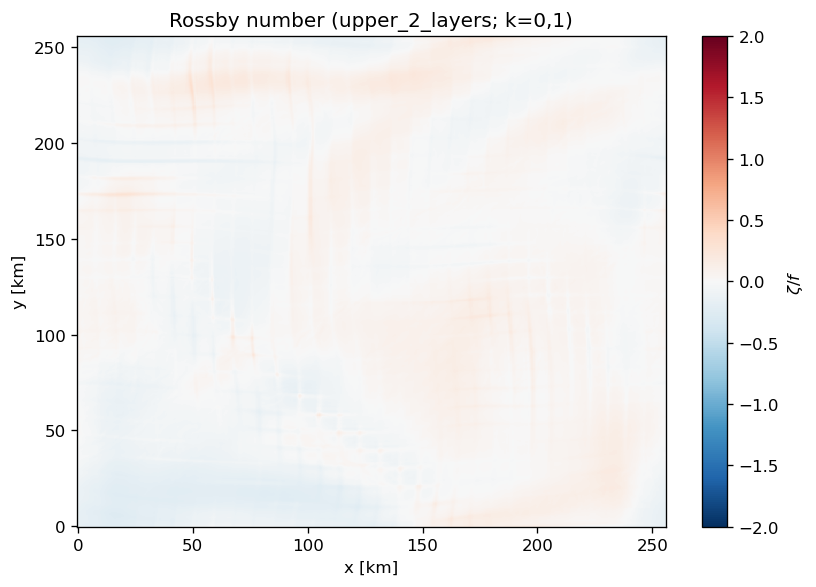

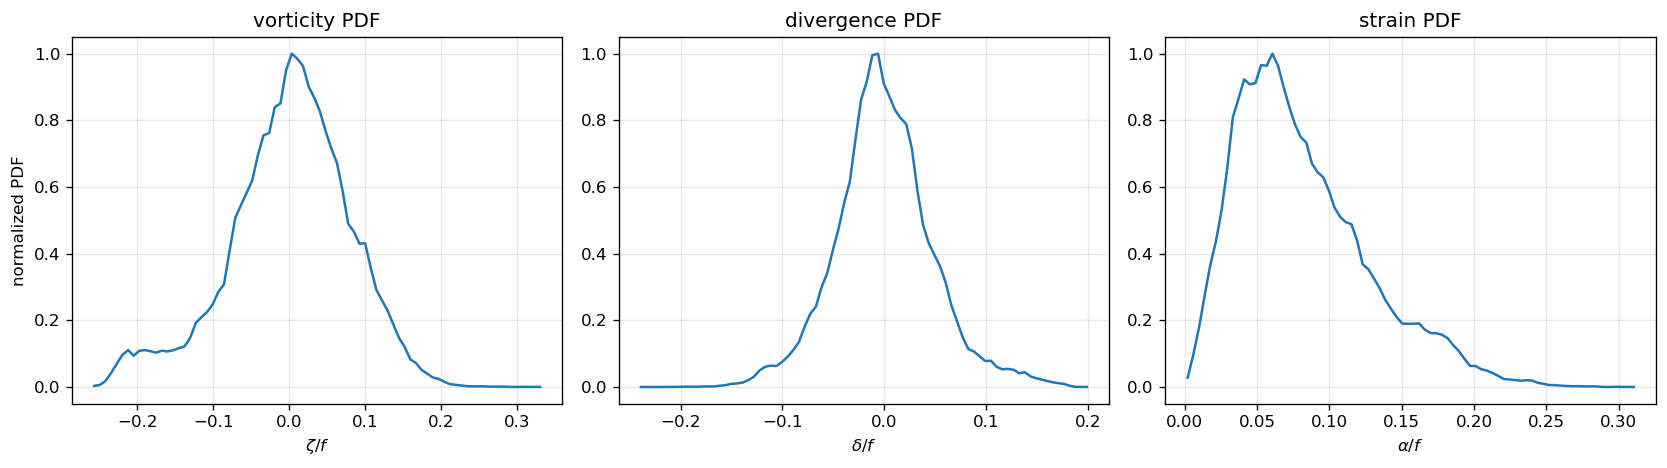

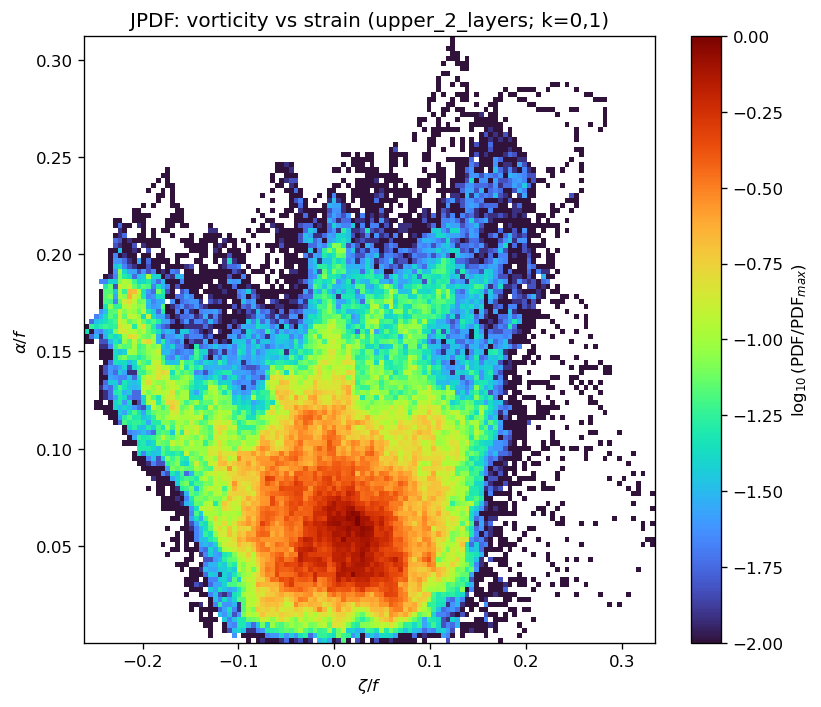

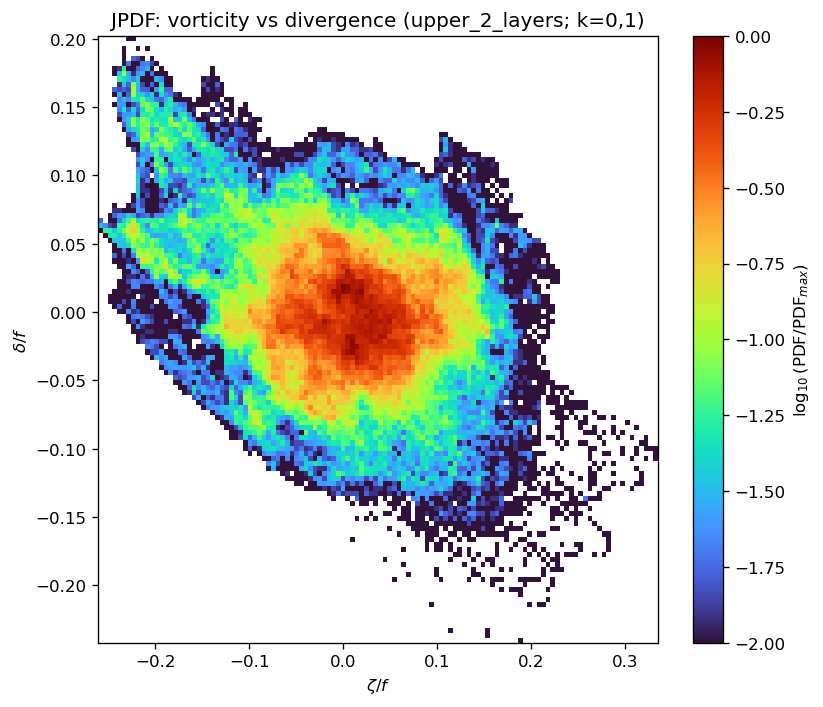

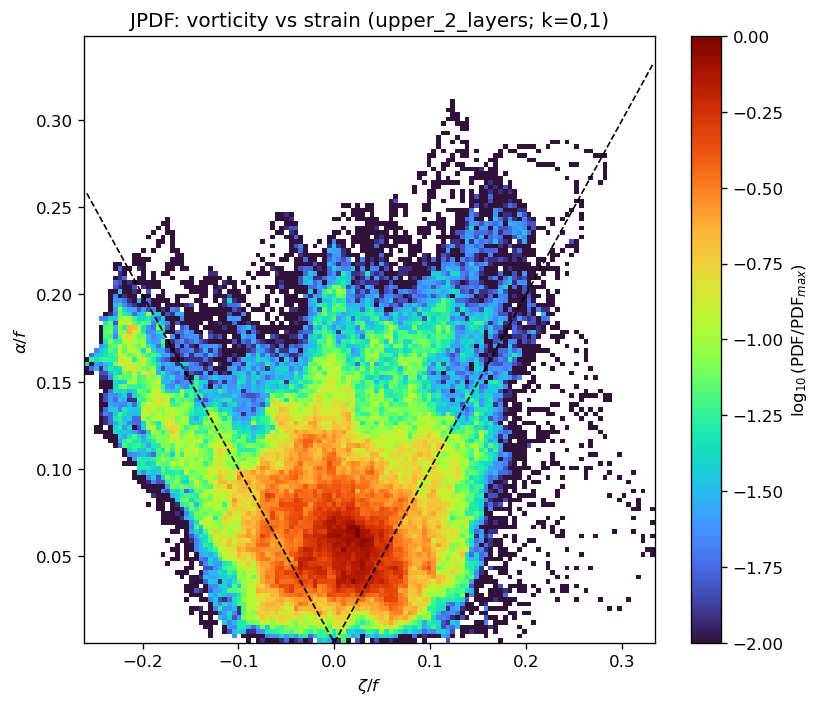

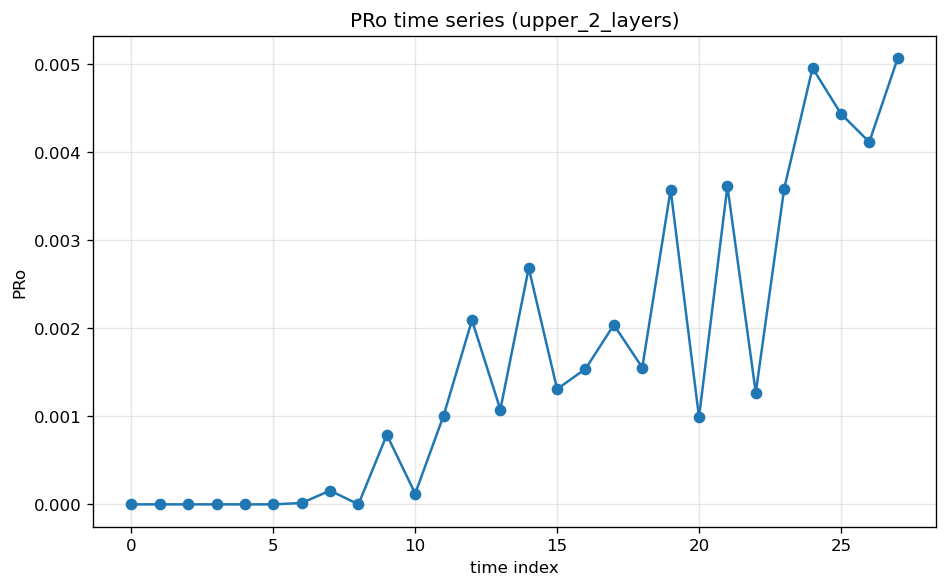

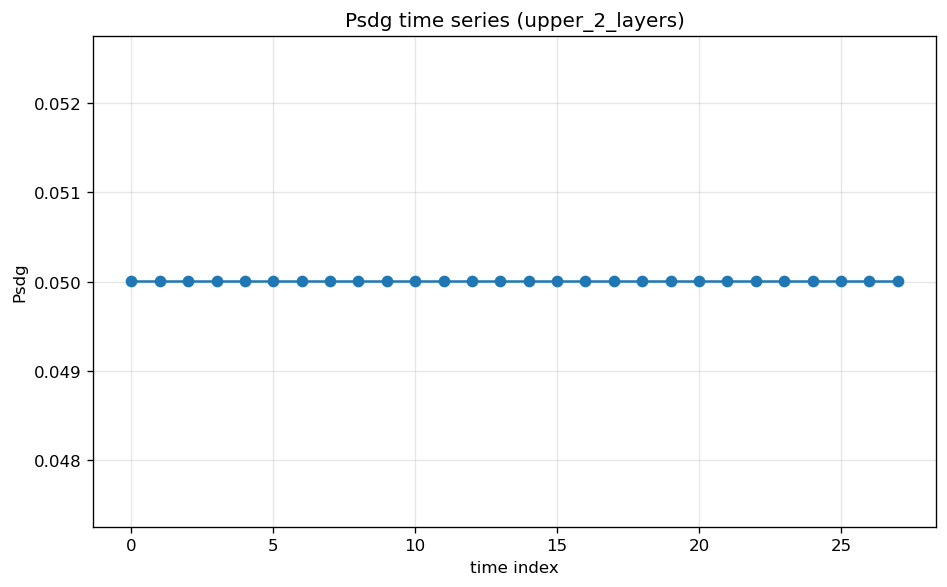

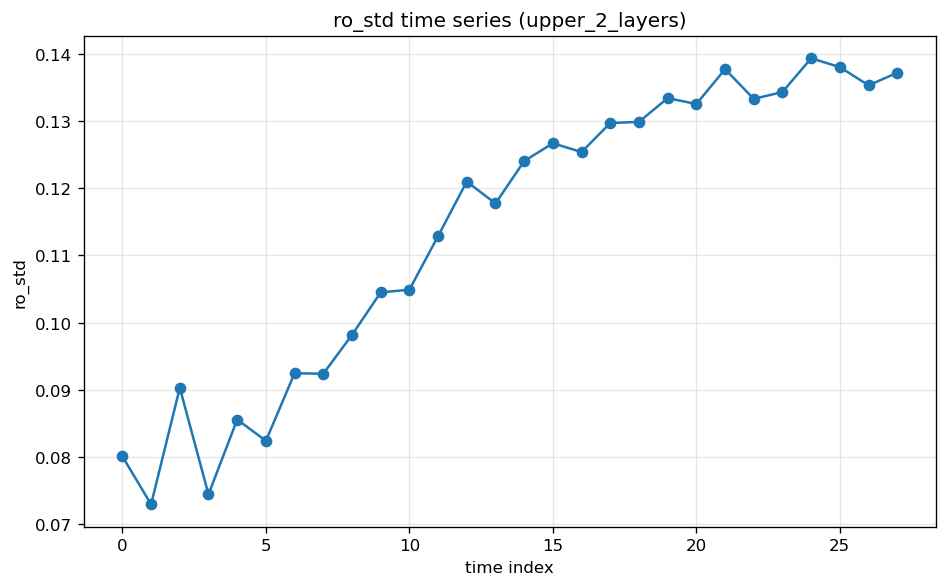

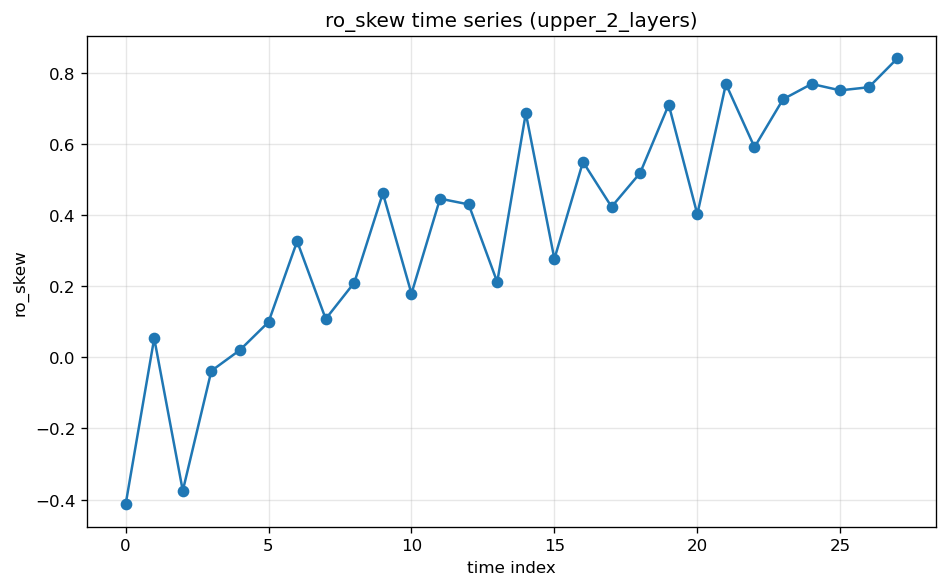


Notebook variables now available:
  ds
  maps_store
  pdf_store
  jpdf_store
  metrics_df


In [6]:
NB_DIR = Path.cwd()
DATA_FILE = (NB_DIR / "../data/input/state_diag.0000000000.glob.nc").resolve()
UTILS_PATH = (NB_DIR / "../scripts").resolve()
MODULE_NAME = "shcherbina_utils"

OUT_DIR = (NB_DIR / "../results/post_shcherbina_upper2").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find glued state file at:\n{DATA_FILE}")

DX = 500.0
DY = 500.0
F0 = 8.0e-5

TOP_LEVELS = [0, 1]
LAYER_LABEL = "k=0,1"

# ------------------------------------------------------------
# TIME SELECTION
# ------------------------------------------------------------
SELECTED_TIME_INDEX = None   # set to None for all times

plot_mode = "upper_2_layers"

nbins_pdf = 80
nbins_jpdf = 120

PRo_threshold = 0.5
Psdg_density_threshold = 4e-5  # kg m^-4

rho0 = 1035.0
tAlpha = 2.0e-4
sBeta = 7.4e-4
tRef = 5.0 * 84.0
sRef = 35.0 * 84.0

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 120

# ------------------------------------------------------------
# IMPORT HELPER MODULE
# ------------------------------------------------------------
if str(UTILS_PATH) not in sys.path:
    sys.path.insert(0, str(UTILS_PATH))

shu = importlib.import_module(MODULE_NAME)
importlib.reload(shu)

find_dim = shu.find_dim
clean_fill = shu.clean_fill
uv_to_center = shu.uv_to_center
gradients_uv = shu.gradients_uv
center_crop = shu.center_crop
normalize_hist = shu.normalize_hist
flatten_finite = shu.flatten_finite
compute_density = shu.compute_density
plot_map = shu.plot_map
plot_jpdf = shu.plot_jpdf

# ------------------------------------------------------------
# SMALL LOCAL HELPERS
# ------------------------------------------------------------
def nan_skew(a):
    a = np.asarray(a, dtype=float)
    mu = np.nanmean(a)
    sig = np.nanstd(a)
    if not np.isfinite(sig) or sig == 0:
        return np.nan
    return np.nanmean((a - mu) ** 3) / sig ** 3

def get_time_value(ds, time_dim, it):
    try:
        return ds[time_dim].isel({time_dim: it}).item()
    except Exception:
        return int(it)

# ------------------------------------------------------------
# OPEN DATA
# ------------------------------------------------------------
print("Opening glued state diagnostics...")
ds = xr.open_dataset(DATA_FILE, chunks="auto")

required_vars = ["UVEL", "VVEL", "THETA"]
for v in required_vars:
    if v not in ds:
        raise KeyError(f"Required variable '{v}' not found in dataset.")

time_dim = find_dim(ds.dims, ["T", "time", "iter"])
z_dim = find_dim(ds["UVEL"].dims, ["Z", "Zmd", "k", "depth"])

nt = ds.sizes[time_dim]
nz = ds.sizes[z_dim]

for k in TOP_LEVELS:
    if k < 0 or k >= nz:
        raise IndexError(f"TOP_LEVELS contains invalid index {k}; nz={nz}")

if SELECTED_TIME_INDEX is None:
    keep_times = np.arange(nt, dtype=int)
else:
    if not (0 <= int(SELECTED_TIME_INDEX) < nt):
        raise IndexError(f"SELECTED_TIME_INDEX={SELECTED_TIME_INDEX} is out of range for nt={nt}")
    keep_times = np.array([int(SELECTED_TIME_INDEX)], dtype=int)

plot_time_index = int(keep_times[0])

has_salt = "SALT" in ds.variables

print(f"time_dim         : {time_dim}")
print(f"z_dim            : {z_dim}")
print(f"n time steps     : {nt}")
print(f"n vertical levels: {nz}")
print(f"selected time    : {SELECTED_TIME_INDEX}")
print(f"using times      : {keep_times.tolist()}")
print(f"SALT present     : {has_salt}")
print(f"TOP_LEVELS       : {TOP_LEVELS}")

# ------------------------------------------------------------
# MAIN ANALYSIS
# ------------------------------------------------------------
maps_store = {}
pdf_store = {}
jpdf_store = {}
metrics_records = []

for it in keep_times:
    print(f"\nProcessing time index {it}")

    layer_results = []

    for k in TOP_LEVELS:
        u = clean_fill(ds["UVEL"].isel({time_dim: it, z_dim: k}).values)
        v = clean_fill(ds["VVEL"].isel({time_dim: it, z_dim: k}).values)
        th = clean_fill(ds["THETA"].isel({time_dim: it, z_dim: k}).values)

        u_c, v_c = uv_to_center(u[None, ...], v[None, ...])
        u_c = u_c[0]
        v_c = v_c[0]

        speed_k, zeta_k, div_k, strain_k = gradients_uv(u_c, v_c, DX, DY)
        ro_k = zeta_k / F0
        div_f_k = div_k / F0
        strain_f_k = strain_k / F0

        th, ro_k, div_f_k, strain_f_k, speed_k = center_crop(th, ro_k, div_f_k, strain_f_k, speed_k)

        if has_salt:
            salt = clean_fill(ds["SALT"].isel({time_dim: it, z_dim: k}).values)
            salt, th = center_crop(salt, th)
            rho_k = compute_density(
                th, salt,
                rho0=rho0, tAlpha=tAlpha, sBeta=sBeta,
                tRef=tRef, sRef=sRef
            )
            rho_k, ro_k, div_f_k, strain_f_k, speed_k = center_crop(
                rho_k, ro_k, div_f_k, strain_f_k, speed_k
            )
            drho_dy, drho_dx = np.gradient(rho_k, DY, DX, axis=(-2, -1))
            grad_rho_k = np.sqrt(drho_dx**2 + drho_dy**2)
        else:
            grad_rho_k = None

        layer_results.append({
            "k": int(k),
            "ro": ro_k,
            "div_f": div_f_k,
            "strain_f": strain_f_k,
            "speed": speed_k,
            "theta": th,
            "grad_rho": grad_rho_k
        })

    ro_2L = np.nanmean(np.stack([d["ro"] for d in layer_results], axis=0), axis=0)
    div_f_2L = np.nanmean(np.stack([d["div_f"] for d in layer_results], axis=0), axis=0)
    strain_f_2L = np.nanmean(np.stack([d["strain_f"] for d in layer_results], axis=0), axis=0)
    speed_2L = np.nanmean(np.stack([d["speed"] for d in layer_results], axis=0), axis=0)
    theta_2L = np.nanmean(np.stack([d["theta"] for d in layer_results], axis=0), axis=0)

    if has_salt and all(d["grad_rho"] is not None for d in layer_results):
        grad_rho_2L = np.nanmean(np.stack([d["grad_rho"] for d in layer_results], axis=0), axis=0)
        Psdg = np.nanmean(grad_rho_2L > Psdg_density_threshold)
        psdg_name = "Psdg"
    else:
        grad_rho_2L = None
        dth_dy, dth_dx = np.gradient(theta_2L, DY, DX, axis=(-2, -1))
        grad_theta = np.sqrt(dth_dx**2 + dth_dy**2)
        proxy_threshold = np.nanpercentile(grad_theta, 95)
        Psdg = np.nanmean(grad_theta > proxy_threshold)
        psdg_name = "Ptheta_proxy"

    PRo = np.nanmean(np.abs(ro_2L) > PRo_threshold)

    key = (int(it), "upper_2_layers")

    maps_store[key] = {
        "ro": ro_2L,
        "div_f": div_f_2L,
        "strain_f": strain_f_2L,
        "speed": speed_2L,
        "theta": theta_2L,
        "grad_rho": grad_rho_2L
    }

    ro_1d, div_1d, strain_1d = flatten_finite(ro_2L, div_f_2L, strain_f_2L)

    ro_pdf, ro_edges = np.histogram(ro_1d, bins=nbins_pdf, density=True)
    div_pdf, div_edges = np.histogram(div_1d, bins=nbins_pdf, density=True)
    strain_pdf, strain_edges = np.histogram(strain_1d, bins=nbins_pdf, density=True)

    pdf_store[key] = {
        "ro_bin": 0.5 * (ro_edges[:-1] + ro_edges[1:]),
        "ro_pdf": normalize_hist(ro_pdf),
        "div_bin": 0.5 * (div_edges[:-1] + div_edges[1:]),
        "div_pdf": normalize_hist(div_pdf),
        "strain_bin": 0.5 * (strain_edges[:-1] + strain_edges[1:]),
        "strain_pdf": normalize_hist(strain_pdf),
    }

    ro_j1, strain_j1 = flatten_finite(ro_2L, strain_f_2L)
    H1, x1e, y1e = np.histogram2d(ro_j1, strain_j1, bins=nbins_jpdf, density=True)

    ro_j2, div_j2 = flatten_finite(ro_2L, div_f_2L)
    H2, x2e, y2e = np.histogram2d(ro_j2, div_j2, bins=nbins_jpdf, density=True)

    jpdf_store[key] = {
        "ro_strain_H": H1,
        "ro_strain_x": 0.5 * (x1e[:-1] + x1e[1:]),
        "ro_strain_y": 0.5 * (y1e[:-1] + y1e[1:]),
        "ro_div_H": H2,
        "ro_div_x": 0.5 * (x2e[:-1] + x2e[1:]),
        "ro_div_y": 0.5 * (y2e[:-1] + y2e[1:]),
    }

    metrics_records.append({
        "time_index": int(it),
        "time_value": get_time_value(ds, time_dim, it),
        "layer_mode": "upper_2_layers",
        "depth_indices": str(TOP_LEVELS),
        "PRo": float(PRo),
        "Psdg": float(Psdg),
        "Psdg_name": psdg_name,
        "ro_mean": float(np.nanmean(ro_2L)),
        "ro_std": float(np.nanstd(ro_2L)),
        "ro_skew": float(nan_skew(ro_2L)),
        "div_f_mean": float(np.nanmean(div_f_2L)),
        "div_f_std": float(np.nanstd(div_f_2L)),
        "div_f_skew": float(nan_skew(div_f_2L)),
        "strain_f_mean": float(np.nanmean(strain_f_2L)),
        "strain_f_std": float(np.nanstd(strain_f_2L)),
        "speed_mean": float(np.nanmean(speed_2L)),
        "speed_rms": float(np.sqrt(np.nanmean(speed_2L**2))),
    })

metrics_df = pd.DataFrame(metrics_records)
print("\nFinished analysis.")
display(metrics_df.head())

# ------------------------------------------------------------
# PLOT SELECTED TIME
# ------------------------------------------------------------
key_plot = (int(plot_time_index), "upper_2_layers")

if key_plot not in maps_store:
    raise KeyError(
        f"{key_plot} not in computed diagnostics. "
        f"Available keys are: {list(maps_store.keys())}"
    )

m = maps_store[key_plot]
p = pdf_store[key_plot]
j = jpdf_store[key_plot]
depths_label = LAYER_LABEL

plot_map(
    m["ro"],
    title=f"Rossby number ({plot_mode}; {depths_label})",
    cbar_label=r"$\zeta/f$",
    cmap="RdBu_r",
    vmin=-2,
    vmax=2,
    dx=DX,
    dy=DY
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(p["ro_bin"], p["ro_pdf"])
axes[0].set_title("vorticity PDF")
axes[0].set_xlabel(r"$\zeta/f$")
axes[0].set_ylabel("normalized PDF")
axes[0].grid(True, alpha=0.3)

axes[1].plot(p["div_bin"], p["div_pdf"])
axes[1].set_title("divergence PDF")
axes[1].set_xlabel(r"$\delta/f$")
axes[1].grid(True, alpha=0.3)

axes[2].plot(p["strain_bin"], p["strain_pdf"])
axes[2].set_title("strain PDF")
axes[2].set_xlabel(r"$\alpha/f$")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plot_jpdf(
    j["ro_strain_x"], j["ro_strain_y"], j["ro_strain_H"],
    xlabel=r"$\zeta/f$",
    ylabel=r"$\alpha/f$",
    title=f"JPDF: vorticity vs strain ({plot_mode}; {depths_label})"
)

plot_jpdf(
    j["ro_div_x"], j["ro_div_y"], j["ro_div_H"],
    xlabel=r"$\zeta/f$",
    ylabel=r"$\delta/f$",
    title=f"JPDF: vorticity vs divergence ({plot_mode}; {depths_label})"
)

H = j["ro_strain_H"]
x = j["ro_strain_x"]
y = j["ro_strain_y"]
Hn = H / np.nanmax(H) if np.nanmax(H) > 0 else H
Hlog = np.log10(np.where(Hn > 0, Hn, np.nan))

plt.figure(figsize=(7, 6))
plt.pcolormesh(x, y, Hlog.T, shading="auto", cmap="turbo", vmin=-2, vmax=0)
plt.colorbar(label=r"$\log_{10}(\mathrm{PDF}/\mathrm{PDF}_{max})$")
plt.xlabel(r"$\zeta/f$")
plt.ylabel(r"$\alpha/f$")
plt.title(f"JPDF: vorticity vs strain ({plot_mode}; {depths_label})")
xx = np.linspace(np.nanmin(x), np.nanmax(x), 500)
plt.plot(xx, np.abs(xx), "k--", lw=1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# METRIC TIME SERIES
# ------------------------------------------------------------
for metric in ["PRo", "Psdg", "ro_std", "ro_skew"]:
    plt.figure(figsize=(8, 5))
    sub = metrics_df.sort_values("time_index")
    plt.plot(sub["time_index"], sub[metric], marker="o")
    plt.xlabel("time index")
    plt.ylabel(metric)
    plt.title(f"{metric} time series ({plot_mode})")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
# metrics_csv = OUT_DIR / "submeso_metrics_upper2.csv"
# metrics_df.to_csv(metrics_csv, index=False)
# print("Saved:", metrics_csv)

print("\nNotebook variables now available:")
print("  ds")
print("  maps_store")
print("  pdf_store")
print("  jpdf_store")
print("  metrics_df")